# Check Example Data Split

This notebook checks properties of example split to see whether desired properties are matched.

In [1]:
import sys
import os

os.chdir("..")

In [2]:
from pathlib import Path

from preprocessing import explore_dataset, train_val_test_split

DATASET_PATH = Path("../data_det_public/data_det_public")
full_data = explore_dataset(DATASET_PATH)
train_data, val_data, test_data = train_val_test_split(full_data)

Disjoint and sums to the whole data:

In [3]:
tr = set(train_data["image_path"])
v = set(val_data["image_path"])
te = set(test_data["image_path"])

print("Train:", len(tr))
print("Val:", len(v))
print("Test:", len(te))

assert len(tr) + len(v) + len(te) == len(full_data), "Some files are missing"
assert len(tr & v) == 0 and len(tr & te) == 0 and len(v & te) == 0, "Some are contained multiple times"

Train: 2072
Val: 259
Test: 259


Correct ratio:

In [8]:
import math

assert math.isclose( len(tr) / len(v), 8 ), "Wrong Train-Val split ratio"
assert math.isclose( len(tr) / len(te), 8 ), "Wrong Train-Test split ratio"
assert math.isclose( len(v) / len(te), 1 ), "Wrong Val-Test split ratio"

Distribution of cities preserved:

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

def show_hist(df: pd.DataFrame) -> None:
    counts = df["city"].value_counts()
    plt.figure(figsize=(10, 5))
    plt.bar(counts.index, counts.values, width=0.6)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

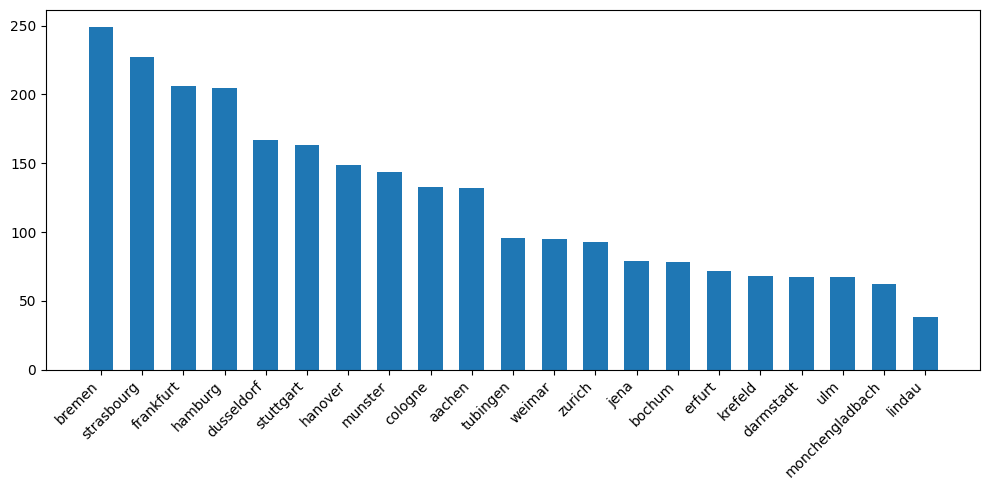

In [11]:
show_hist(full_data)

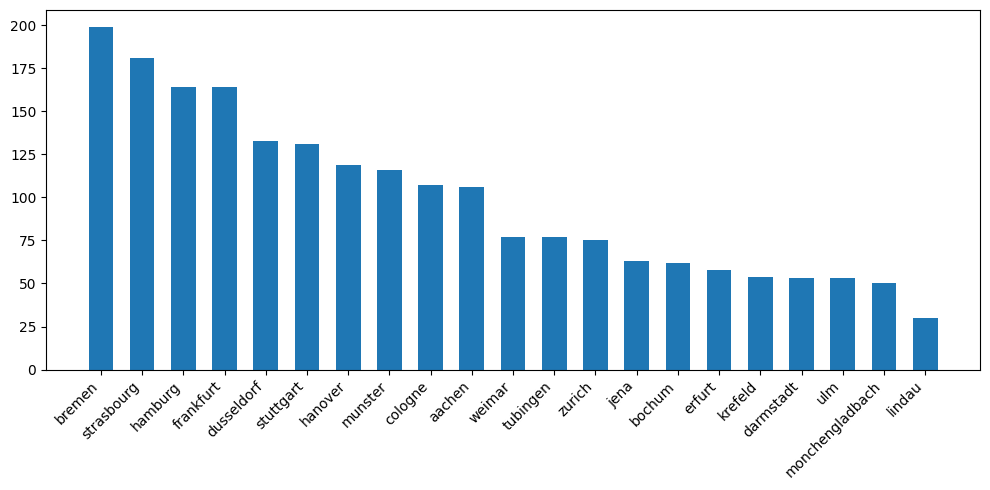

In [12]:
show_hist(train_data)

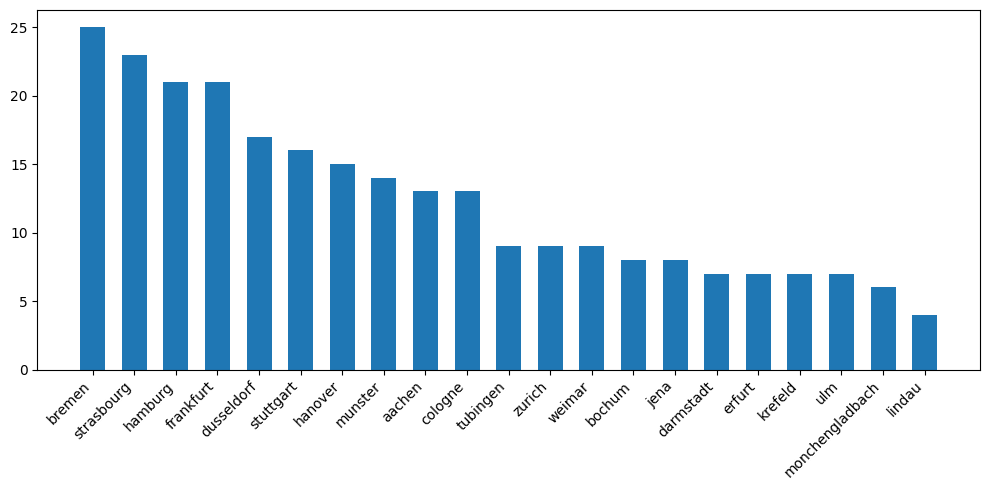

In [13]:
show_hist(val_data)

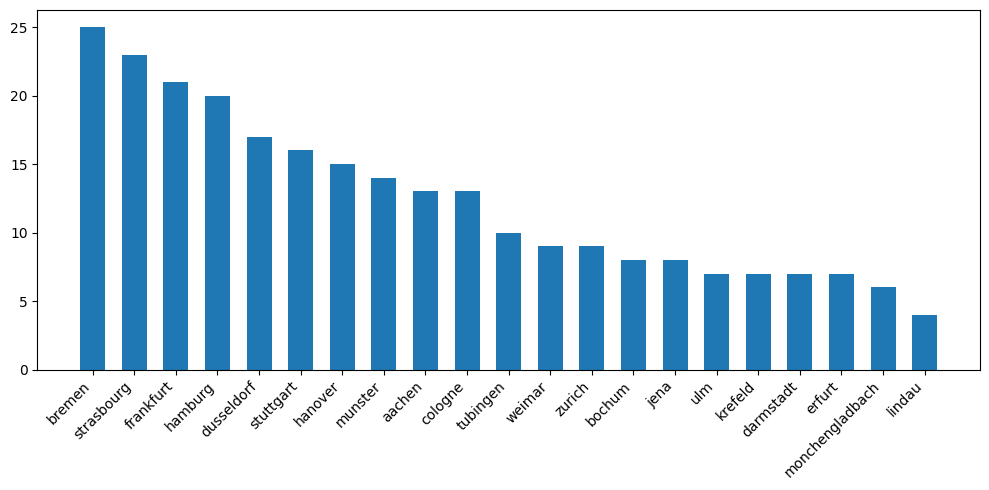

In [14]:
show_hist(test_data)